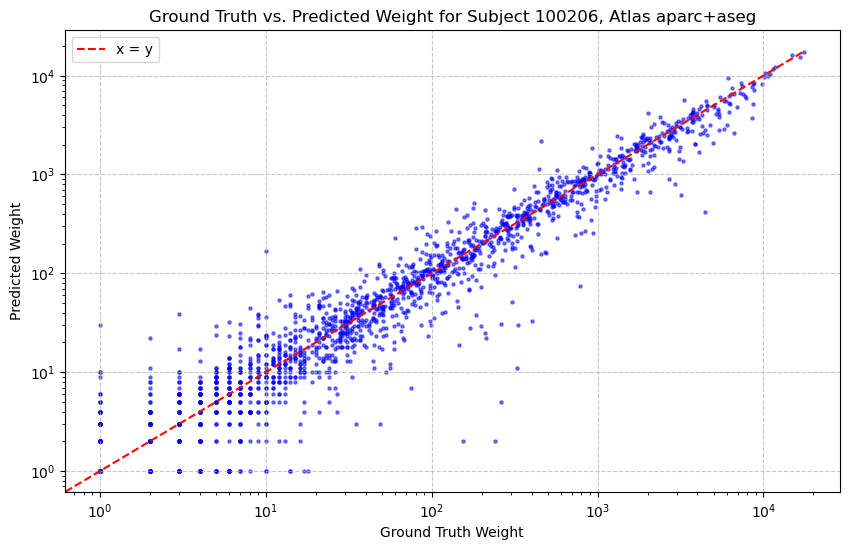

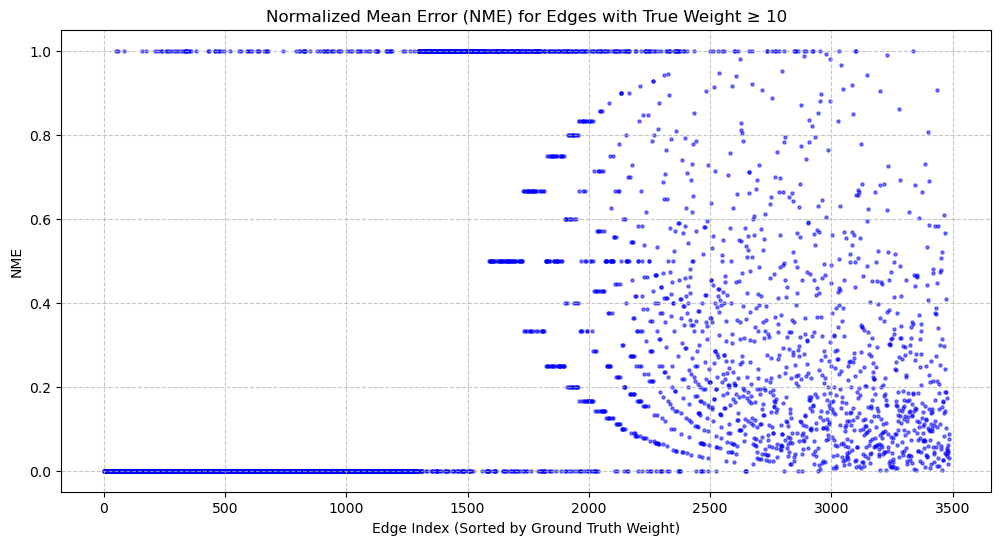

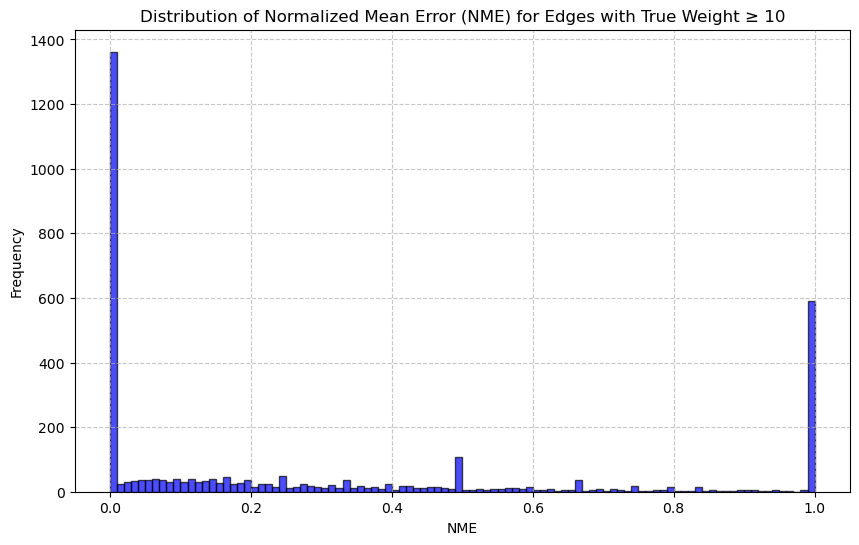

Mean Filtered NME: 0.31085771244214855
Standard Deviation of Filtered NME: 0.37790870119740577


In [27]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

class ConnectomeData:
    def __init__(self, folder_path):
        """
        Initialize the ConnectomeData class.

        Args:
            folder_path (str): Path to the folder containing all CSV files.
        """
        self.folder_path = folder_path
        self.data = {}
        self._load_data()

    def _load_data(self):
        """
        Load all connectome files from the folder and organize them.

        File names are expected to follow the pattern:
        {subject_id}_connectome_{atlas}_{pred}.csv
        """
        for file_name in os.listdir(self.folder_path):
            if file_name.endswith(".csv"):
                parts = file_name.split("_")
                if len(parts) < 4:
                    continue

                subject_id = parts[0]
                atlas = parts[2]
                connectome_type = parts[3].replace(".csv", "")

                if subject_id not in self.data:
                    self.data[subject_id] = {}

                if atlas not in self.data[subject_id]:
                    self.data[subject_id][atlas] = {}

                # Load the CSV file into a DataFrame
                file_path = os.path.join(self.folder_path, file_name)
                self.data[subject_id][atlas][connectome_type] = pd.read_csv(file_path, header=None).values

    def get_connectome(self, subject_id, atlas, connectome_type):
        """
        Retrieve a connectome matrix for a given subject, atlas, and type.

        Args:
            subject_id (str): The subject ID.
            atlas (str): The atlas name (e.g., "aparc+aseg").
            connectome_type (str): The type of connectome (e.g., "pred").

        Returns:
            np.ndarray: The connectome matrix.

        Raises:
            KeyError: If the requested data is not found.
        """
        try:
            return self.data[subject_id][atlas][connectome_type]
        except KeyError:
            raise KeyError(f"Connectome for subject '{subject_id}', atlas '{atlas}', and type '{connectome_type}' not found.")

    def plot_scatter_ground_truth_vs_predicted(self, subject_id, atlas):
        """
        Plot scatter of ground truth vs. predicted connectome weights.
        """
        true_matrix = self.get_connectome(subject_id, atlas, "true")
        pred_matrix = self.get_connectome(subject_id, atlas, "pred")

        triu_indices = np.triu_indices_from(true_matrix, k=1)
        true_upper = true_matrix[triu_indices]
        pred_upper = pred_matrix[triu_indices]

        plt.figure(figsize=(10, 6))
        plt.scatter(true_upper, pred_upper, alpha=0.5, color="blue", s=5)
        plt.title(f"Ground Truth vs. Predicted Weight for Subject {subject_id}, Atlas {atlas}")
        plt.xlabel("Ground Truth Weight")
        plt.ylabel("Predicted Weight")
        plt.xscale("log")
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.plot([min(true_upper), max(true_upper)], [min(true_upper), max(true_upper)], color="red", linestyle="--", label="x = y")
        plt.legend()
        plt.show()

    def plot_normalized_difference(self, subject_id, atlas):
        """
        Plot normalized absolute difference between ground truth and predicted connectome weights.
        """
        true_matrix = self.get_connectome(subject_id, atlas, "true")
        pred_matrix = self.get_connectome(subject_id, atlas, "pred")

        triu_indices = np.triu_indices_from(true_matrix, k=1)
        true_upper = true_matrix[triu_indices]
        pred_upper = pred_matrix[triu_indices]

        differences = np.abs(true_upper - pred_upper)
        normalized_difference = differences / (true_upper + 1e-10)

        plt.figure(figsize=(10, 6))
        plt.scatter(true_upper, normalized_difference, alpha=0.5, color="blue", s=5)
        plt.title(f"Normalized Absolute Difference vs. Ground Truth Weight for Subject {subject_id}, Atlas {atlas}")
        plt.xlabel("Ground Truth Weight")
        plt.ylabel("Normalized Absolute Difference")
        plt.xscale("log")
        plt.ylim(0, 1)
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.show()

    def plot_sorted_weights(self, subject_id, atlas):
        """
        Plot sorted ground truth and predicted weights.
        """
        true_matrix = self.get_connectome(subject_id, atlas, "true")
        pred_matrix = self.get_connectome(subject_id, atlas, "pred")

        triu_indices = np.triu_indices_from(true_matrix, k=1)
        true_upper = true_matrix[triu_indices]
        pred_upper = pred_matrix[triu_indices]

        sorted_indices = np.argsort(-true_upper)
        sorted_true = true_upper[sorted_indices]
        sorted_pred = pred_upper[sorted_indices]

        plt.figure(figsize=(10, 6))
        plt.plot(sorted_true, label="Ground Truth", color="blue")
        plt.plot(sorted_pred, label="Predicted", color="orange")
        plt.title(f"Sorted Weights for Subject {subject_id}, Atlas {atlas}")
        plt.xlabel("Connection Index (Sorted)")
        plt.ylabel("Weight")
        plt.xscale("log")
        plt.legend()
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.show()

    def plot_regression_log_log(self, subject_id, atlas):
        """
        Plot regression in log-log space between ground truth and predicted weights.
        """
        true_matrix = self.get_connectome(subject_id, atlas, "true")
        pred_matrix = self.get_connectome(subject_id, atlas, "pred")

        triu_indices = np.triu_indices_from(true_matrix, k=1)
        true_upper = true_matrix[triu_indices]
        pred_upper = pred_matrix[triu_indices]

        log_true = np.log(true_upper + 1e-10)
        log_pred = np.log(pred_upper + 1e-10)

        reg_model = LinearRegression()
        reg_model.fit(log_true.reshape(-1, 1), log_pred)
        slope = reg_model.coef_[0]
        intercept = reg_model.intercept_

        x = np.linspace(np.min(true_upper), np.max(true_upper), 1000)
        reg_line = np.exp(intercept) * (x ** slope)

        plt.figure(figsize=(10, 6))
        plt.scatter(true_upper, pred_upper, alpha=0.5, color="blue", s=5, label="Data")
        plt.plot(x, x, label="x = y", color="red", linestyle="--")
        plt.plot(x, reg_line, label=f"Regression (slope={slope:.2f})", color="green")
        plt.title(f"Log-Log Regression for Subject {subject_id}, Atlas {atlas}")
        plt.xlabel("Ground Truth Weight")
        plt.ylabel("Predicted Weight")
        plt.xscale("log")
        plt.yscale("log")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.legend()
        plt.show()
        
    def NME_dist(self, subject_id, atlas):
        true = self.get_connectome(subject_id, atlas, "true")
        pred = self.get_connectome(subject_id, atlas, "pred")
        
        # Use the upper triangle only, excluding the diagonal
        triu_indices = np.triu_indices_from(true, k=1)
        true_upper = true[triu_indices]
        pred_upper = pred[triu_indices]

        # Filter out values where the true connectome weight is less than 10
        filter_mask = true_upper >= 0
        filtered_true_upper = true_upper[filter_mask]
        filtered_pred_upper = pred_upper[filter_mask]

        # Compute the normalized mean error (NME) for filtered edges
        epsilon = 1e-10  # Small value to avoid division by zero
        filtered_nme = np.abs(filtered_true_upper - filtered_pred_upper) / (np.abs(filtered_true_upper) + epsilon)

        # Clip NME values to a maximum of 1
        filtered_nme = np.clip(filtered_nme, 0, 1)

        # Sort edges by the ground truth values for a clearer plot
        sorted_indices = np.argsort(filtered_true_upper)
        sorted_filtered_true_upper = filtered_true_upper[sorted_indices]
        sorted_filtered_nme = filtered_nme[sorted_indices]

        # Plot the NME for filtered edges
        plt.figure(figsize=(12, 6))
        plt.scatter(range(len(sorted_filtered_nme)), sorted_filtered_nme, alpha=0.5, color="blue", s=5)
        plt.title("Normalized Mean Error (NME) for Edges with True Weight ≥ 10")
        plt.xlabel("Edge Index (Sorted by Ground Truth Weight)")
        plt.ylabel("NME")
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.yscale("linear")  # Use linear scale since values are clipped between 0 and 1
        plt.show()

        # Create the plot for the distribution of filtered NME values
        plt.figure(figsize=(10, 6))
        plt.hist(filtered_nme, bins=100, alpha=0.7, color='blue', edgecolor='black')

        # Add labels and title
        plt.xlabel('NME')
        plt.ylabel('Frequency')
        plt.title('Distribution of Normalized Mean Error (NME) for Edges with True Weight ≥ 10')

        # Show the plot
        plt.grid(True, linestyle="--", alpha=0.7)
        plt.show()

        # Print mean and standard deviation of the filtered NME
        print(f'Mean Filtered NME: {np.mean(filtered_nme)}')
        print(f'Standard Deviation of Filtered NME: {np.std(filtered_nme)}')

# Usage example
folder_path = "D:/Code/ExternshipLocal/results/"
connectome_data = ConnectomeData(folder_path)

subject_id = "100206"
atlas = "aparc+aseg"
try:
    connectome_data.plot_scatter_ground_truth_vs_predicted(subject_id, atlas)
    # connectome_data.plot_normalized_difference(subject_id, atlas)
    # connectome_data.plot_sorted_weights(subject_id, atlas)
    # connectome_data.plot_regression_log_log(subject_id, atlas)
    connectome_data.NME_dist(subject_id, atlas)
except KeyError as e:
    print(e)


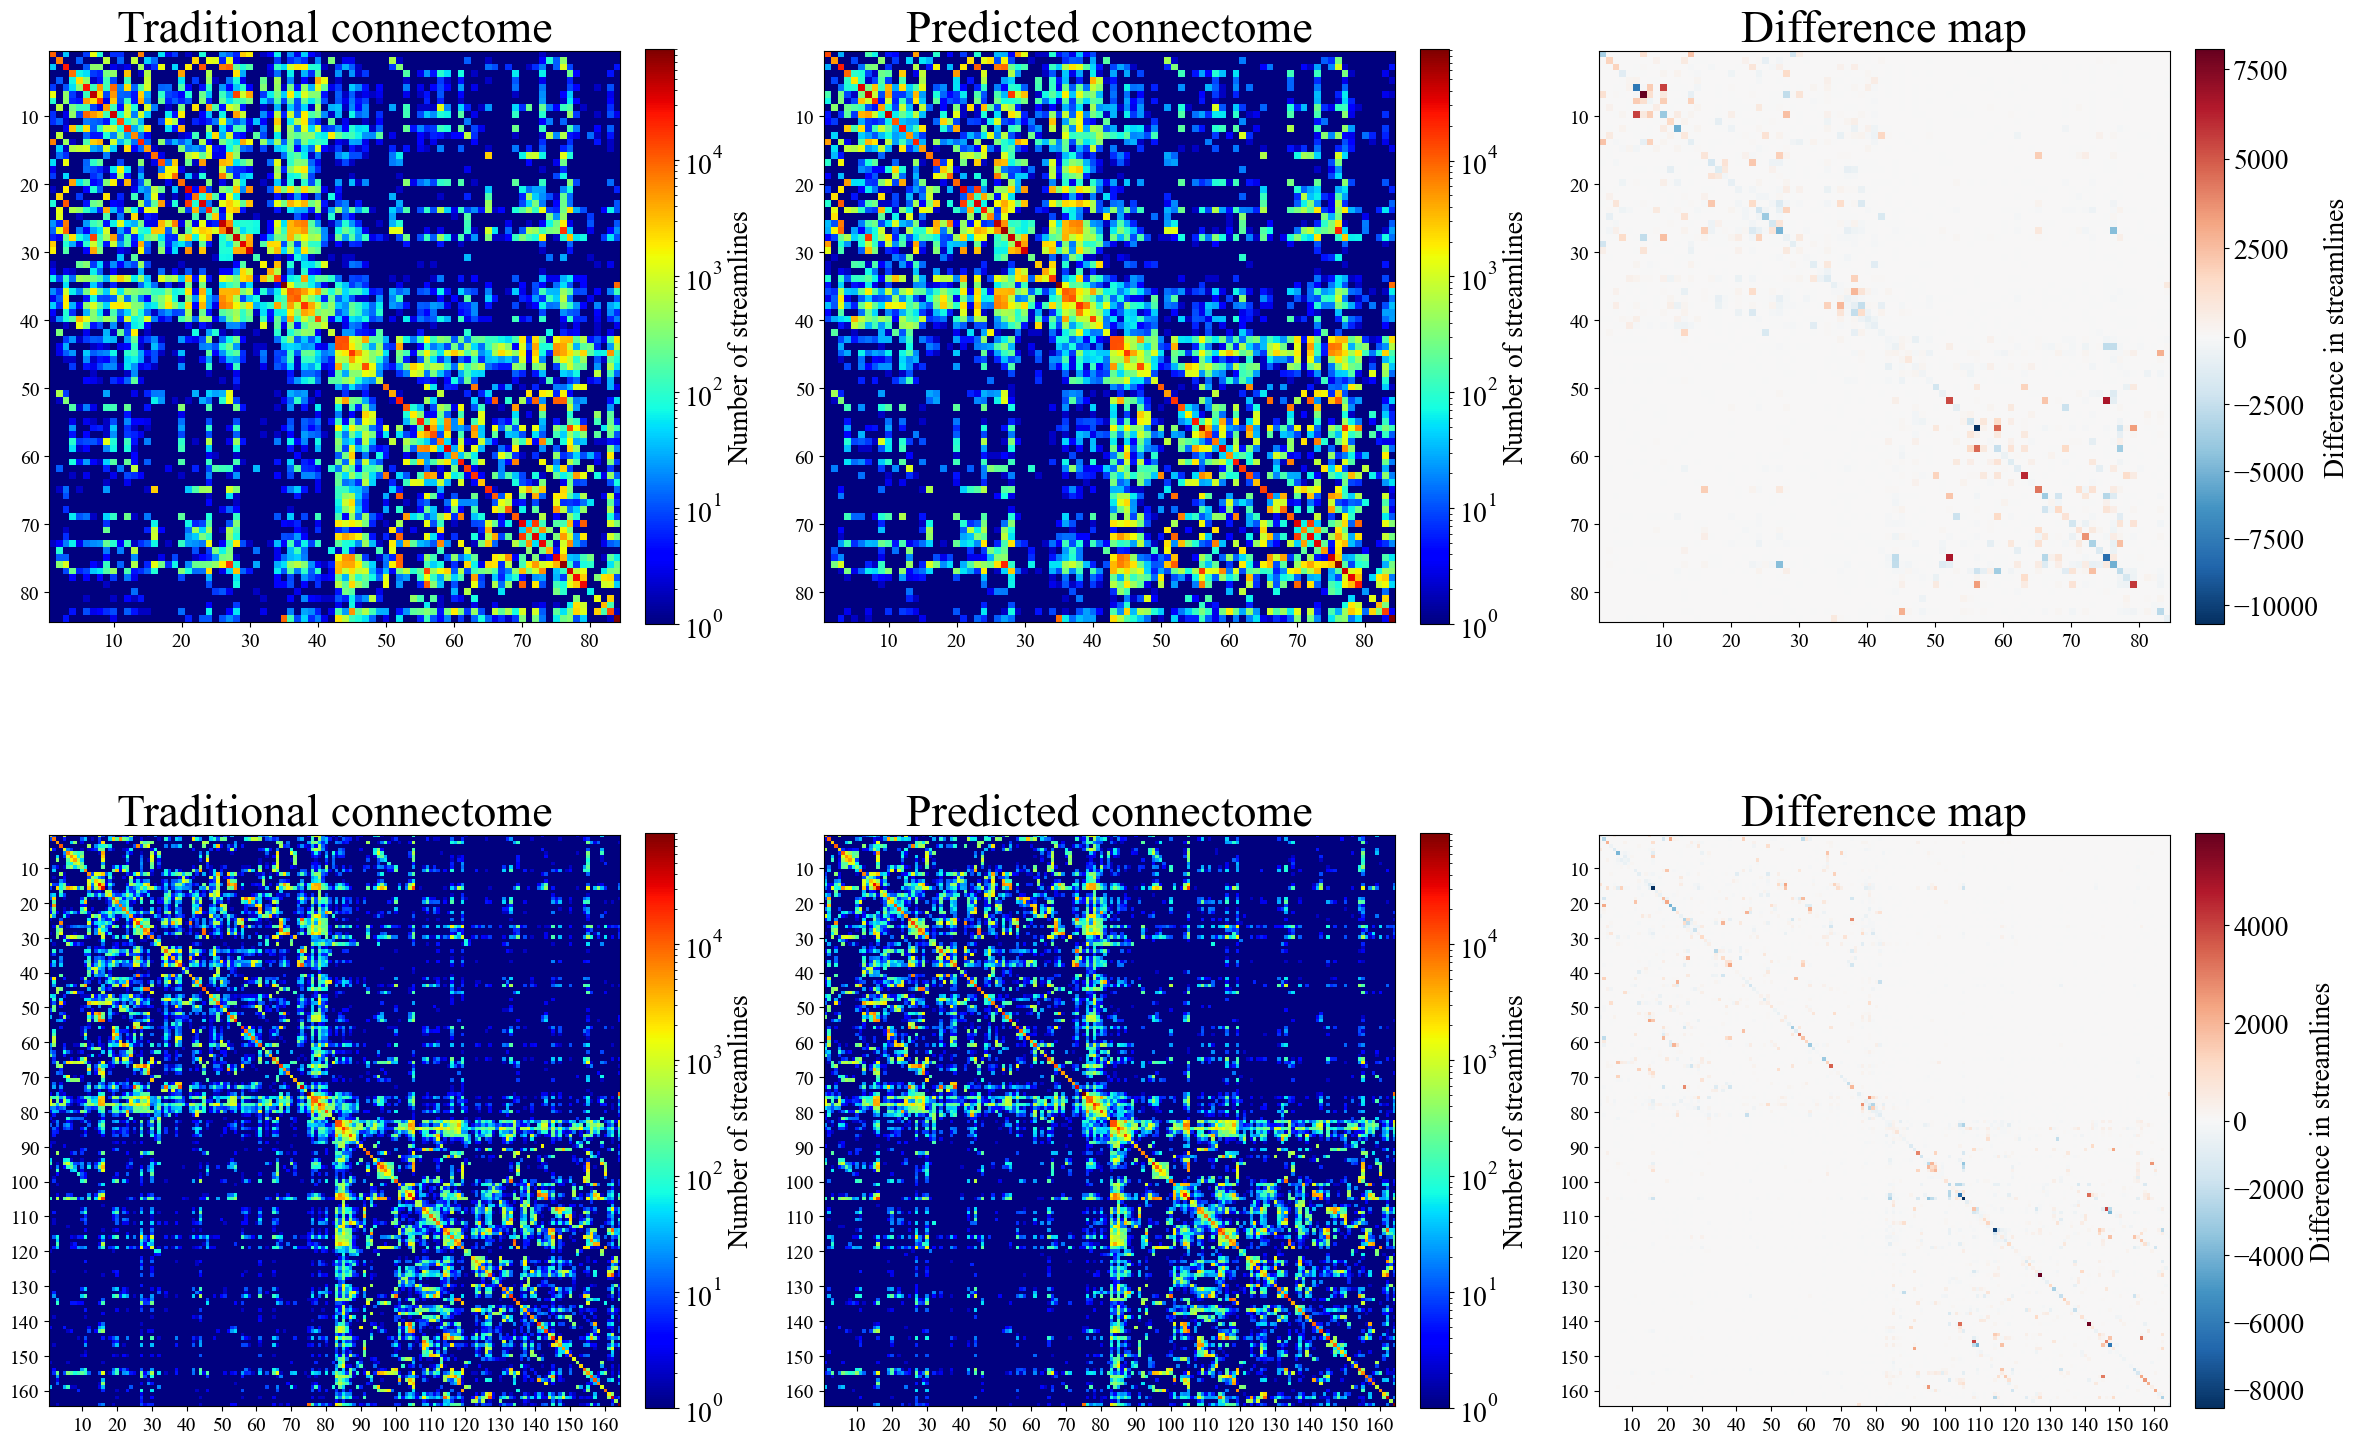

In [21]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd

# Set font style
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 20  # Larger font size

# File paths
files = {
    "aparc+aseg": {
        "true": r"D:/code/ExternshipLocal/results/connectomes/965367_connectome_aparc+aseg_true.csv",
        "pred": r"D:/code/ExternshipLocal/results/connectomes/965367_connectome_aparc+aseg_pred.csv"
    },
    "aparc.a2009s+aseg": {
        "true": r"D:/code/ExternshipLocal/results/connectomes/965367_connectome_aparc.a2009s+aseg_true.csv",
        "pred": r"D:/code/ExternshipLocal/results/connectomes/965367_connectome_aparc.a2009s+aseg_pred.csv"
    }
}

# Load connectomes
connectomes = {}
for atlas, paths in files.items():
    connectomes[atlas] = {
        "true": pd.read_csv(paths["true"], header=None).values,
        "pred": pd.read_csv(paths["pred"], header=None).values
    }
    connectomes[atlas]["diff"] = connectomes[atlas]["true"] - connectomes[atlas]["pred"]

# Plot function with optional ticks
def plot_matrix(ax, matrix, title, difference=False, log_scale=False, show_ticks=False):
    if difference == True:
        if not log_scale:
            cmap = plt.get_cmap('RdBu_r')  # Red-white-blue colormap
            norm = mcolors.TwoSlopeNorm(
                vmin=matrix.min(), vcenter=0, vmax=matrix.max())
        if log_scale:
            cmap = plt.get_cmap('Reds')  # Red-white-blue colormap
            norm = mcolors.LogNorm(
                vmin=max(matrix.min(), 1), vmax=matrix.max())
            matrix = np.where(
                matrix == 0, 1e-6, matrix)
    elif difference == 'percent':
        cmap = plt.get_cmap('RdBu_r')  # Red-white-blue colormap
        norm = mcolors.TwoSlopeNorm(vmin=-1, vcenter=0, vmax=1)
    elif difference == 'accuracy':
        cmap = plt.get_cmap('BuGn')
        norm = mcolors.TwoSlopeNorm(vmin=0, vcenter=0.5, vmax=1)
    else:
        cmap = plt.get_cmap('jet')

        if log_scale:
            norm = mcolors.LogNorm(
                vmin=max(matrix.min(), 1), vmax=matrix.max())
            # Handle zero values by replacing them with a small positive value for log scale
            matrix = np.where(
                matrix == 0, 1e-6, matrix)
        else:
            norm = None

    im = ax.imshow(matrix, cmap=cmap, norm=norm)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    if difference:
        cbar.set_label('Difference in streamlines', fontsize=20)
    else:
        cbar.set_label('Number of streamlines', fontsize=20)

    ax.set_title(title, fontsize=33)

    # Show/hide ticks
    if show_ticks:
        num_nodes = matrix.shape[0]
        ax.set_xticks(np.arange(9, num_nodes, 10))
        ax.set_xticklabels(np.arange(10, num_nodes, 10), fontsize=14)
        ax.set_yticks(np.arange(9, num_nodes, 10))
        ax.set_yticklabels(np.arange(10, num_nodes, 10), fontsize=14)
    else:
        ax.set_xticks([])
        ax.set_yticks([])

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(24, 16))

# Set tick visibility
show_ticks = True  # Change to True if you want ticks

# Plot all subplots
for i, (atlas, data) in enumerate(connectomes.items()):
    plot_matrix(axes[i, 0], data["true"], f"Traditional connectome", log_scale=True, show_ticks=show_ticks)
    plot_matrix(axes[i, 1], data["pred"], f"Predicted connectome", log_scale=True, show_ticks=show_ticks)
    plot_matrix(axes[i, 2], data["diff"], f"Difference map", difference=True, show_ticks=show_ticks)

plt.tight_layout()
plt.savefig("figure5_ticks.png", dpi=1000, bbox_inches="tight")
plt.show()


In [ ]:
# Compute MAPE
true_flat = data['true'].flatten()
pred_flat = data['pred'].flatten()

# Avoid division by zero by adding a small epsilon
epsilon = 1e-10
mape = np.mean(np.abs((true_flat - pred_flat) / (true_flat + epsilon))) * 100

# Print the result
print(f"Mean Absolute Percentage Error (MAPE): {mape:.6f}%")

Metrics already computed. Loading from D:/Code/ExternshipLocal/results/metrics/aparc+aseg_metrics.csv
Metrics already computed. Loading from D:/Code/ExternshipLocal/results/metrics/aparc.a2009s+aseg_metrics.csv

==========Statistical Analysis for aparc+aseg atlas==========

Descriptive Statistics:
LERM: Intra: 7.249±1.348, Inter: 10.755±0.874
LERM: Intra - Skewness: 0.682, Kurtosis: 2.965
LERM: Inter - Skewness: 2.456, Kurtosis: 14.350
LERM: Intra - Shapiro-Wilk Test: W = 0.968, p = 0.00014
LERM: Inter - Shapiro-Wilk Test: W = 0.847, p = 0.00000

Statistical Analysis (Paired t-test, Cohen's d, Percentage Improvement):
LERM: t(200) = -44.951, p = 0.00000
Effect Size (Cohen's d): LERM: d = -3.171
Percentage Improvement (LERM): -32.60%
Significant difference found between intra and inter LERM.

Descriptive Statistics:
r: Intra: 0.992±0.003, Inter: 0.963±0.008
r: Intra - Skewness: -1.518, Kurtosis: 3.431
r: Inter - Skewness: -2.450, Kurtosis: 12.643
r: Intra - Shapiro-Wilk Test: W = 0.890,

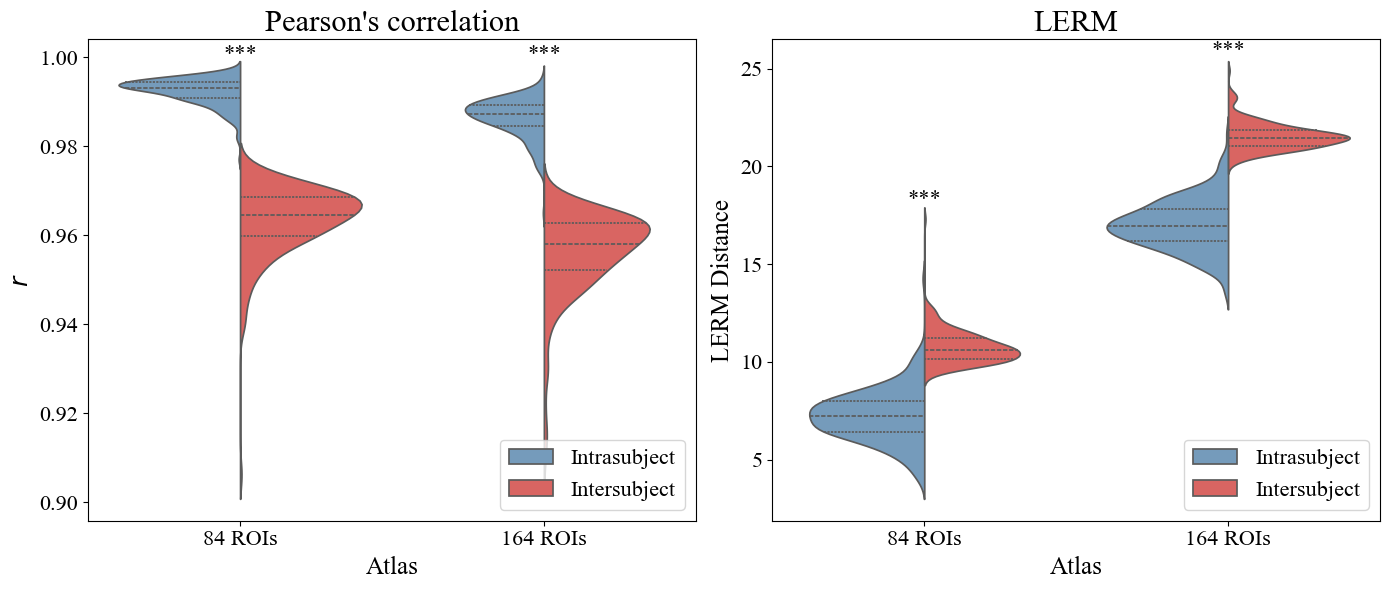

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from sklearn.linear_model import LinearRegression
from scipy.linalg import logm, norm
import scipy.stats as stats
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from scipy.stats import permutation_test
from sklearn.utils import resample


class ConnectomeData:
    def __init__(self, folder_path, output_folder):
        self.folder_path = folder_path
        self.output_folder = output_folder
        self.data = {}
        self._load_data()

    def _load_data(self):
        for file_name in os.listdir(self.folder_path):
            if file_name.endswith(".csv"):
                parts = file_name.split("_")
                if len(parts) < 4:
                    continue

                subject_id = parts[0]
                atlas = parts[2]
                connectome_type = parts[3].replace(".csv", "")

                if subject_id not in self.data:
                    self.data[subject_id] = {}
                if atlas not in self.data[subject_id]:
                    self.data[subject_id][atlas] = {}

                file_path = os.path.join(self.folder_path, file_name)
                self.data[subject_id][atlas][connectome_type] = pd.read_csv(
                    file_path, header=None).values

    def get_connectome(self, subject_id, atlas, connectome_type, upper=False):
        try:
            matrix = self.data[subject_id][atlas][connectome_type]
            if upper:
                # k=0 includes diagonal
                return matrix[np.triu_indices_from(matrix, k=0)]
            else:
                return matrix

        except KeyError:
            raise KeyError(
                f"Connectome for subject '{subject_id}', atlas '{atlas}', and type '{connectome_type}' not found.")

    def compute_metrics(self, atlas):
        metrics = {}

        # Check if metrics have already been computed and saved
        metrics_file = os.path.join(self.output_folder, f"{atlas}_metrics.csv")
        if os.path.exists(metrics_file):
            print(f"Metrics already computed. Loading from {metrics_file}")
            return pd.read_csv(metrics_file).to_dict()  # Convert to dict

        # c=0
        # Compute intra and inter-subject metrics
        for subject_id in self.data:
            # if c==11:
            #     break
            # c+=1
            metrics[subject_id] = {
                "intra_LERM": np.nan,
                "intra_r": np.nan,
                "inter_LERM": np.nan,
                "inter_r": np.nan,
                "inter_LERM_all": [],
                "inter_r_all": []
            }

            if atlas in self.data[subject_id]:
                true = self.get_connectome(subject_id, atlas, "true")
                pred = self.get_connectome(subject_id, atlas, "pred")

                # Intra-subject: distance between predicted and true for the same subject
                metrics[subject_id]["intra_LERM"] = norm(
                    logm(pred) - logm(true), 'fro')
                metrics[subject_id]["intra_r"] = np.corrcoef(pred[np.triu_indices_from(
                    pred, k=0)], true[np.triu_indices_from(true, k=0)])[1, 0]

                # Inter-subject: distance between predicted connectome of one subject and true connectome of all other subjects
                for other_id in self.data:
                    if other_id != subject_id and atlas in self.data[other_id]:
                        true_other = self.get_connectome(
                            other_id, atlas, "true")
                        # Append inter-subject values instead of overwriting
                        metrics[subject_id]["inter_LERM_all"].append(
                            norm(logm(pred) - logm(true_other), 'fro'))
                        metrics[subject_id]["inter_r_all"].append(np.corrcoef(pred[np.triu_indices_from(
                            pred, k=0)], true_other[np.triu_indices_from(true_other, k=0)])[1, 0])

                # Compute mean inter values for printing
                metrics[subject_id]["inter_LERM"] = np.mean(
                    metrics[subject_id]["inter_LERM_all"])
                metrics[subject_id]["inter_r"] = np.mean(
                    metrics[subject_id]["inter_r_all"])

            print(
                f"subject {subject_id} done {metrics[subject_id]['intra_LERM']:.3f} vs {np.mean(metrics[subject_id]['inter_LERM']):.3f} and {metrics[subject_id]['intra_r']:.3f} vs {np.mean(metrics[subject_id]['inter_r']):.3f}")

        # Save metrics to a CSV file for future use
        metrics_df = pd.DataFrame.from_dict(metrics, orient='index')
        metrics_df.to_csv(metrics_file)

        return metrics  # Returning the metrics dictionary

    from statsmodels.stats.multitest import fdrcorrection

    def analyze_metrics(self, atlas):
        metrics_file = os.path.join(self.output_folder, f"{atlas}_metrics.csv")

        if not os.path.exists(metrics_file):
            print(f"Metrics file for {atlas} not found!")
            return

        # Load metrics from file
        metrics_df = pd.read_csv(metrics_file, index_col=0)

        # Extract intra and inter metrics for LERM and r
        metrics = {
            "LERM": {"intra": metrics_df['intra_LERM'], "inter": metrics_df['inter_LERM']},
            "r": {"intra": metrics_df['intra_r'], "inter": metrics_df['inter_r']}
        }
        del metrics_df  # Remove reference
        gc.collect()

        p_values = []  # To store p-values for FDR correction
        metrics_for_fdr = []  # Store which metrics the p-values correspond to

        # Paired t-tests, Effect size, Normality check, and Percentage improvement
        print(f"\n==========Statistical Analysis for {atlas} atlas==========")
        for metric in metrics:
            intra = metrics[metric]["intra"]
            inter = metrics[metric]["inter"]

            # Descriptive statistics
            print("\nDescriptive Statistics:")
            print(f"{metric}: Intra: {np.mean(intra):.3f}±{np.std(intra, ddof=1):.3f}, Inter: {np.mean(inter):.3f}±{np.std(inter, ddof=1):.3f}")

            # Skewness and Kurtosis
            print(
                f"{metric}: Intra - Skewness: {stats.skew(intra):.3f}, Kurtosis: {stats.kurtosis(intra):.3f}")
            print(
                f"{metric}: Inter - Skewness: {stats.skew(inter):.3f}, Kurtosis: {stats.kurtosis(inter):.3f}")

            # Normality test (Shapiro-Wilk)
            print(
                f"{metric}: Intra - Shapiro-Wilk Test: W = {stats.shapiro(intra)[0]:.3f}, p = {stats.shapiro(intra)[1]:.5f}")
            print(
                f"{metric}: Inter - Shapiro-Wilk Test: W = {stats.shapiro(inter)[0]:.3f}, p = {stats.shapiro(inter)[1]:.5f}")

            # Statistical Analysis
            print(
                "\nStatistical Analysis (Paired t-test, Cohen's d, Percentage Improvement):")
            # Paired t-test
            t_stat, p_val = stats.ttest_rel(intra, inter)
            df = len(intra) - 1
            print(f"{metric}: t({df}) = {t_stat:.3f}, p = {p_val:.5f}")

            # Collect p-values for FDR correction
            p_values.append(p_val)
            metrics_for_fdr.append(metric)

            # Effect size (Cohen's d)
            d = (np.mean(intra) - np.mean(inter)) / \
                np.std(intra - inter, ddof=1)
            print(f"Effect Size (Cohen's d): {metric}: d = {d:.3f}")

            # Percentage improvement
            improvement = (np.mean(intra) - np.mean(inter)) / \
                np.mean(inter) * 100
            print(f"Percentage Improvement ({metric}): {improvement:.2f}%")

            # Interpretation of significance (Before FDR correction)
            if p_val < 0.05:
                print(
                    f"Significant difference found between intra and inter {metric}.")
            else:
                print(
                    f"No significant difference between intra and inter {metric}.")

        # Apply FDR correction to all p-values
        rejected, corrected_p_values, _, _ = multipletests(
            p_values, alpha=0.05, method='fdr_bh')

        # Adjust significance interpretation based on corrected p-values
        for i, metric in enumerate(metrics_for_fdr):
            corrected_p_val = corrected_p_values[i]
            print(f"\n{metric} (Corrected for FDR):")
            if corrected_p_val < 0.05:
                print(
                    f"Significant difference found after FDR correction, corrected p = {corrected_p_val:.5f}")
            else:
                print(
                    f"No significant difference after FDR correction, corrected p = {corrected_p_val:.5f}")

    def plot_double_violin(self, atlases):
        if isinstance(atlases, str):
            # Convert single atlas to a list if only one is provided
            atlases = [atlases]

        # Initialize empty lists to hold the data for both atlases
        plot_df_LERM_list = []
        plot_df_r_list = []

        # Loop through the atlases and load the data for each
        for atlas in atlases:
            metrics_file = os.path.join(
                self.output_folder, f"{atlas}_metrics.csv")

            if not os.path.exists(metrics_file):
                print(f"Metrics file for {atlas} not found!")
                continue

            # Load metrics from file
            metrics_df = pd.read_csv(metrics_file, index_col=0)

            # Extract intra and inter metrics for LERM and r
            intra_LERM = metrics_df['intra_LERM']
            intra_r = metrics_df['intra_r']
            inter_LERM = metrics_df['inter_LERM']
            inter_r = metrics_df['inter_r']
            del metrics_df  # Remove reference
            gc.collect()

            if atlas == "aparc+aseg":
                atlas_roi = "84 ROIs"
            if atlas == "aparc.a2009s+aseg":
                atlas_roi = "164 ROIs"

            # Create DataFrame for plotting for LERM and r for each atlas
            plot_df_LERM = pd.DataFrame({
                'Type': ['Intrasubject'] * len(intra_LERM) + ['Intersubject'] * len(inter_LERM),
                'Value': list(intra_LERM) + list(inter_LERM),
                'Atlas': [atlas_roi] * (len(intra_LERM) + len(inter_LERM))
            })

            plot_df_r = pd.DataFrame({
                'Type': ['Intrasubject'] * len(intra_r) + ['Intersubject'] * len(inter_r),
                'Value': list(intra_r) + list(inter_r),
                'Atlas': [atlas_roi] * (len(intra_r) + len(inter_r))
            })

            # Append to the list
            plot_df_LERM_list.append(plot_df_LERM)
            plot_df_r_list.append(plot_df_r)

        # Concatenate the data for both atlases
        plot_df_LERM_combined = pd.concat(plot_df_LERM_list, ignore_index=True)
        plot_df_r_combined = pd.concat(plot_df_r_list, ignore_index=True)

        # Define the custom colors
        palette_LERM = ["#699cc7", "#ed524e"]
        palette_r = ["#699cc7", "#ed524e"]

        # Set the font to Times New Roman and increase font size
        plt.rcParams.update({
            'font.family': 'Times New Roman',
            'axes.labelsize': 16,
            'xtick.labelsize': 16,
            'ytick.labelsize': 16,
            'legend.fontsize': 16
        })

        # Create the subplots
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Plot r comparison for both atlases
        sns.violinplot(x='Atlas', y='Value', data=plot_df_r_combined, hue='Type',
                       split=True, inner="quart", ax=axes[0], legend=True, palette=palette_r)
        axes[0].set_title("Pearson's correlation", fontsize=22)
        axes[0].set_xlabel('Atlas', fontsize=18)
        axes[0].set_ylabel('$\it{r}$', fontsize=18)
        axes[0].legend(loc='lower right')

        # Plot LERM comparison for both atlases
        sns.violinplot(x='Atlas', y='Value', data=plot_df_LERM_combined, hue='Type',
                       split=True, inner="quart", ax=axes[1], legend=True, palette=palette_LERM)
        axes[1].set_title("LERM", fontsize=22)
        axes[1].set_xlabel('Atlas', fontsize=18)
        axes[1].set_ylabel('LERM Distance', fontsize=18)
        axes[1].legend(loc='lower right')

        # Collect p-values for each comparison (LERM and r tests)
        p_vals_LERM = []
        p_vals_r = []

        for i, atlas in enumerate(atlases):
            intra_LERM = np.array(
                plot_df_LERM_list[i]['Value'][plot_df_LERM_list[i]['Type'] == 'Intrasubject'])
            inter_LERM = np.array(
                plot_df_LERM_list[i]['Value'][plot_df_LERM_list[i]['Type'] == 'Intersubject'])
            intra_r = np.array(
                plot_df_r_list[i]['Value'][plot_df_r_list[i]['Type'] == 'Intrasubject'])
            inter_r = np.array(
                plot_df_r_list[i]['Value'][plot_df_r_list[i]['Type'] == 'Intersubject'])

            # Normality check with Shapiro-Wilk test
            LERM_normal = stats.shapiro(intra_LERM)[
                1] > 0.05 and stats.shapiro(inter_LERM)[1] > 0.05
            r_normal = stats.shapiro(
                intra_r)[1] > 0.05 and stats.shapiro(inter_r)[1] > 0.05

            # Define colors for significance annotations
            color_normal = "b"  # Blue for t-test (normal distribution)
            # Black for Wilcoxon (non-normal distribution)
            color_non_normal = "k"

            # Check normality and apply appropriate statistical test
            if LERM_normal:
                _, LERM_p_val = stats.ttest_rel(intra_LERM, inter_LERM)
                LERM_color = color_normal
            else:
                _, LERM_p_val = stats.wilcoxon(intra_LERM, inter_LERM)
                LERM_color = color_non_normal

            if r_normal:
                _, r_p_val = stats.ttest_rel(intra_r, inter_r)
                r_color = color_normal
            else:
                _, r_p_val = stats.wilcoxon(intra_r, inter_r)
                r_color = color_non_normal

            p_vals_LERM.append(LERM_p_val)
            p_vals_r.append(r_p_val)

        # Apply FDR correction to p-values
        reject_LERM, corrected_p_vals_LERM, _, _ = multipletests(
            p_vals_LERM, alpha=0.001, method='fdr_bh')
        reject_r, corrected_p_vals_r, _, _ = multipletests(
            p_vals_r, alpha=0.001, method='fdr_bh')

        # Use corrected p-values for significance annotations
        for i, atlas in enumerate(atlases):
            # Get corrected p-values for this atlas
            LERM_p_val = corrected_p_vals_LERM[i]
            r_p_val = corrected_p_vals_r[i]

            # Adjust as needed
            y_max_LERM = max(
                plot_df_LERM_list[i]['Value'][plot_df_LERM_list[i]['Type'] == 'Intersubject']) + 0.75

            # Annotate statistical significance with colored stars
            axes[0].annotate(
                ("n.s." if r_p_val >= 0.05 else ("*" if r_p_val >= 0.01 else (
                    "**" if r_p_val >= 0.001 else "***"))),
                xy=(i, 0.9995),
                ha='center',
                fontsize=16,
                color=r_color  # Use color based on test
            )

            axes[1].annotate(
                ("n.s." if LERM_p_val >= 0.05 else ("*" if LERM_p_val >= 0.01 else (
                    "**" if LERM_p_val >= 0.001 else "***"))),
                xy=(i, y_max_LERM),
                ha='center',
                fontsize=16,
                color=LERM_color  # Use color based on test
            )

        # Adjust layout
        plt.tight_layout()
        axes[0].get_legend().set_title("")
        axes[1].get_legend().set_title("")
        plt.show()


# Usage example
folder_path = "D:/Code/ExternshipLocal/results/connectomes/"
output_folder = "D:/Code/ExternshipLocal/results/metrics/"
connectome_data = ConnectomeData(folder_path, output_folder)

try:
    metrics = connectome_data.compute_metrics("aparc+aseg")
    metrics = connectome_data.compute_metrics("aparc.a2009s+aseg")
    connectome_data.analyze_metrics("aparc+aseg")
    connectome_data.analyze_metrics("aparc.a2009s+aseg")
    connectome_data.plot_double_violin(["aparc+aseg", "aparc.a2009s+aseg"])
    # connectome_data.plot_double_violin(["aparc+aseg"])
except KeyError as e:
    print(e)

In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gc
from sklearn.linear_model import LinearRegression
from scipy.linalg import logm, norm
import scipy.stats as stats
import seaborn as sns
from statsmodels.stats.multitest import multipletests
from scipy.stats import permutation_test


class ConnectomeData:
    def __init__(self, folder_path, output_folder, retest_folder_path=None):
        """
        If retest_folder_path is provided, the class loads data for a test–retest experiment.
        Otherwise, it loads data for the predicted vs. ground truth evaluation.
        """
        self.folder_path = folder_path
        self.retest_folder_path = retest_folder_path  # For test-retest experiments
        self.output_folder = output_folder
        self.data = {}
        if self.retest_folder_path is None:
            self._load_data()  # Original loading (expects files with types like 'true', 'pred')
        else:
            # Load from both folders (expects types like 'test' and 'retest')
            self._load_test_retest_data()

    def _load_data(self):
        # Original loader: reads all CSVs from a single folder.
        for file_name in os.listdir(self.folder_path):
            if file_name.endswith(".csv"):
                parts = file_name.split("_")
                if len(parts) < 4:
                    continue
                subject_id = parts[0]
                atlas = parts[2]
                connectome_type = parts[3].replace(".csv", "")
                if subject_id not in self.data:
                    self.data[subject_id] = {}
                if atlas not in self.data[subject_id]:
                    self.data[subject_id][atlas] = {}
                file_path = os.path.join(self.folder_path, file_name)
                self.data[subject_id][atlas][connectome_type] = pd.read_csv(
                    file_path, header=None).values

    def _load_test_retest_data(self):
        # Load test data (from folder_path)
        for file_name in os.listdir(self.folder_path):
            if file_name.endswith(".csv"):
                parts = file_name.split("_")
                if len(parts) < 4:
                    continue
                subject_id = parts[0]
                atlas = parts[2]
                # Expecting these files to be labeled as "test"
                connectome_type = parts[3].replace(".csv", "")
                if subject_id not in self.data:
                    self.data[subject_id] = {}
                if atlas not in self.data[subject_id]:
                    self.data[subject_id][atlas] = {}
                self.data['test'][subject_id][atlas][connectome_type] = pd.read_csv(
                    os.path.join(self.folder_path, file_name), header=None).values

        # Load retest data (from retest_folder_path)
        for file_name in os.listdir(self.retest_folder_path):
            if file_name.endswith(".csv"):
                parts = file_name.split("_")
                if len(parts) < 4:
                    continue
                subject_id = parts[0]
                atlas = parts[2]
                # Expecting these files to be labeled as "retest"
                connectome_type = parts[3].replace(".csv", "")
                if subject_id not in self.data:
                    self.data[subject_id] = {}
                if atlas not in self.data[subject_id]:
                    self.data[subject_id][atlas] = {}
                self.data['retest'][subject_id][atlas][connectome_type] = pd.read_csv(
                    os.path.join(self.retest_folder_path, file_name), header=None).values

    def get_connectome(self, subject_id, atlas, connectome_type, upper=False):
        try:
            matrix = self.data[subject_id][atlas][connectome_type]
            if upper:
                # k=0 includes diagonal
                return matrix[np.triu_indices_from(matrix, k=0)]
            else:
                return matrix
        except KeyError:
            raise KeyError(
                f"Connectome for subject '{subject_id}', atlas '{atlas}', and type '{connectome_type}' not found.")

    def compute_metrics(self, atlas):
        metrics = {}
        # Choose a different filename for test-retest metrics if applicable
        if self.retest_folder_path is None:
            metrics_file = os.path.join(
                self.output_folder, f"{atlas}_metrics.csv")
        else:
            metrics_file = os.path.join(
                self.output_folder, f"{atlas}_metrics_test_retest.csv")

        # If metrics have been computed before, load them
        if os.path.exists(metrics_file):
            print(f"Metrics already computed. Loading from {metrics_file}")
            return pd.read_csv(metrics_file).to_dict()

        if self.retest_folder_path is None:
            # --- Original predicted vs. ground truth computation ---
            for subject_id in self.data:
                metrics[subject_id] = {
                    "intra_LERM": np.nan,
                    "intra_r": np.nan,
                    "inter_LERM": np.nan,
                    "inter_r": np.nan,
                    "inter_LERM_all": [],
                    "inter_r_all": []
                }
                if atlas in self.data[subject_id]:
                    true = self.get_connectome(subject_id, atlas, "true")
                    pred = self.get_connectome(subject_id, atlas, "pred")

                    # Intra-subject: predicted vs. true for the same subject
                    metrics[subject_id]["intra_LERM"] = norm(
                        logm(pred) - logm(true), 'fro')
                    metrics[subject_id]["intra_r"] = np.corrcoef(pred[np.triu_indices_from(
                        pred, k=0)], true[np.triu_indices_from(true, k=0)])[1, 0]

                    # Inter-subject: predicted vs. true from other subjects
                    for other_id in self.data:
                        if other_id != subject_id and atlas in self.data[other_id]:
                            true_other = self.get_connectome(
                                other_id, atlas, "true")
                            metrics[subject_id]["inter_LERM_all"].append(
                                norm(logm(pred) - logm(true_other), 'fro'))
                            metrics[subject_id]["inter_r_all"].append(np.corrcoef(pred[np.triu_indices_from(
                                pred, k=0)], true_other[np.triu_indices_from(true_other, k=0)])[1, 0])

                    metrics[subject_id]["inter_LERM"] = np.mean(
                        metrics[subject_id]["inter_LERM_all"]) if metrics[subject_id]["inter_LERM_all"] else np.nan
                    metrics[subject_id]["inter_r"] = np.mean(
                        metrics[subject_id]["inter_r_all"]) if metrics[subject_id]["inter_r_all"] else np.nan

                    print(f"subject {subject_id} done: intra_LERM={metrics[subject_id]['intra_LERM']:.3f} vs inter_LERM={metrics[subject_id]['inter_LERM']:.3f}, "
                          f"intra_r={metrics[subject_id]['intra_r']:.3f} vs inter_r={metrics[subject_id]['inter_r']:.3f}")
        else:
            # --- Test–retest computation: comparing 'test' and 'retest' connectomes ---
            for subject_id in self.data:
                if atlas in self.data[subject_id] and "test" in self.data[subject_id][atlas] and "retest" in self.data[subject_id][atlas]:
                    test_matrix = self.get_connectome(
                        subject_id, atlas, "test")
                    retest_matrix = self.get_connectome(
                        subject_id, atlas, "retest")
                    metrics[subject_id] = {
                        "intra_LERM": norm(logm(test_matrix) - logm(retest_matrix), 'fro'),
                        "intra_r": np.corrcoef(test_matrix[np.triu_indices_from(test_matrix, k=0)],
                                               retest_matrix[np.triu_indices_from(retest_matrix, k=0)])[1, 0],
                        "inter_LERM": np.nan,
                        "inter_r": np.nan,
                        "inter_LERM_all": [],
                        "inter_r_all": []
                    }

                    # For inter-subject metrics, compare the test connectome of the current subject
                    # with the retest connectomes of all other subjects.
                    for other_id in self.data:
                        if other_id != subject_id and atlas in self.data[other_id] and "retest" in self.data[other_id][atlas]:
                            retest_other = self.get_connectome(
                                other_id, atlas, "retest")
                            metrics[subject_id]["inter_LERM_all"].append(
                                norm(logm(test_matrix) - logm(retest_other), 'fro'))
                            metrics[subject_id]["inter_r_all"].append(np.corrcoef(test_matrix[np.triu_indices_from(test_matrix, k=0)],
                                                                                  retest_other[np.triu_indices_from(retest_other, k=0)])[1, 0])
                    metrics[subject_id]["inter_LERM"] = np.mean(
                        metrics[subject_id]["inter_LERM_all"]) if metrics[subject_id]["inter_LERM_all"] else np.nan
                    metrics[subject_id]["inter_r"] = np.mean(
                        metrics[subject_id]["inter_r_all"]) if metrics[subject_id]["inter_r_all"] else np.nan

                    print(f"subject {subject_id} done: intra_LERM={metrics[subject_id]['intra_LERM']:.3f} vs inter_LERM={metrics[subject_id]['inter_LERM']:.3f}, "
                          f"intra_r={metrics[subject_id]['intra_r']:.3f} vs inter_r={metrics[subject_id]['inter_r']:.3f}")
                else:
                    print(
                        f"subject {subject_id} does not have both test and retest data for atlas {atlas}. Skipping.")

        # Save the computed metrics for future use.
        metrics_df = pd.DataFrame.from_dict(metrics, orient='index')
        metrics_df.to_csv(metrics_file)
        return metrics  # Return the metrics dictionary

    def analyze_metrics(self, atlas):
        # Choose metrics file based on whether we are in test–retest mode.
        if self.retest_folder_path is None:
            metrics_file = os.path.join(
                self.output_folder, f"{atlas}_metrics.csv")
        else:
            metrics_file = os.path.join(
                self.output_folder, f"{atlas}_metrics_test_retest.csv")

        if not os.path.exists(metrics_file):
            print(f"Metrics file for {atlas} not found!")
            return

        metrics_df = pd.read_csv(metrics_file, index_col=0)
        intra_LERM = metrics_df['intra_LERM']
        intra_r = metrics_df['intra_r']
        inter_LERM = metrics_df['inter_LERM']
        inter_r = metrics_df['inter_r']
        del metrics_df
        gc.collect()

        print("\nDescriptive Statistics:")
        print(
            f"Intra_LERM: {np.mean(intra_LERM):.3f}±{np.std(intra_LERM, ddof=1):.3f}")
        print(
            f"Inter_LERM: {np.mean(inter_LERM):.3f}±{np.std(inter_LERM, ddof=1):.3f}")
        print(f"Intra_r: {np.mean(intra_r):.3f}±{np.std(intra_r, ddof=1):.3f}")
        print(f"Inter_r: {np.mean(inter_r):.3f}±{np.std(inter_r, ddof=1):.3f}")

        print("\nStatistical Analysis (Paired t-test):")
        LERM_t_stat, LERM_p_val = stats.ttest_rel(intra_LERM, inter_LERM)
        r_t_stat, r_p_val = stats.ttest_rel(intra_r, inter_r)
        df_LERM = len(intra_LERM) - 1
        df_r = len(intra_r) - 1
        print(
            f"Intra vs Inter LERM: t({df_LERM}) = {LERM_t_stat:.3f}, p = {LERM_p_val:.5f}")
        print(
            f"Intra vs Inter r: t({df_r}) = {r_t_stat:.3f}, p = {r_p_val:.5f}")

        LERM_d = (np.mean(intra_LERM) - np.mean(inter_LERM)) / \
            np.std(intra_LERM - inter_LERM, ddof=1)
        r_d = (np.mean(intra_r) - np.mean(inter_r)) / \
            np.std(intra_r - inter_r, ddof=1)
        print("Effect Size (Cohen's d):")
        print(f"LERM: d = {LERM_d:.3f}")
        print(f"r: d = {r_d:.3f}")

        LERM_improvement = (np.mean(intra_LERM) -
                            np.mean(inter_LERM)) / np.mean(inter_LERM) * 100
        r_improvement = (np.mean(intra_r) - np.mean(inter_r)
                         ) / np.mean(inter_r) * 100
        print("\nPercentage Improvement (Relative to Inter Condition):")
        print(f"LERM: {LERM_improvement:.2f}%")
        print(f"r: {r_improvement:.2f}%")

        if LERM_p_val < 0.05:
            print("Significant difference found between intra and inter LERM.")
        else:
            print("No significant difference between intra and inter LERM.")

        if r_p_val < 0.05:
            print("Significant difference found between intra and inter r.")
        else:
            print("No significant difference between intra and inter r.")

    def permutation_test(self, data1, data2, num_permutations=1000):
        observed_diff = np.mean(data1) - np.mean(data2)
        combined = np.concatenate([data1, data2])
        diffs = []
        for _ in range(num_permutations):
            np.random.shuffle(combined)
            perm_data1 = combined[:len(data1)]
            perm_data2 = combined[len(data1):]
            diffs.append(np.mean(perm_data1) - np.mean(perm_data2))
        p_value = np.mean(np.abs(diffs) >= np.abs(observed_diff))
        return p_value

    def plot_double_violin(self, atlases):
        # This plotting function remains largely the same.
        if isinstance(atlases, str):
            atlases = [atlases]

        plot_df_LERM_list = []
        plot_df_r_list = []

        for atlas in atlases:
            # Use the appropriate metrics file based on mode
            if self.retest_folder_path is None:
                metrics_file = os.path.join(
                    self.output_folder, f"{atlas}_metrics.csv")
            else:
                metrics_file = os.path.join(
                    self.output_folder, f"{atlas}_metrics_test_retest.csv")

            if not os.path.exists(metrics_file):
                print(f"Metrics file for {atlas} not found!")
                continue

            metrics_df = pd.read_csv(metrics_file, index_col=0)
            intra_LERM = metrics_df['intra_LERM']
            intra_r = metrics_df['intra_r']
            inter_LERM = metrics_df['inter_LERM']
            inter_r = metrics_df['inter_r']
            del metrics_df
            gc.collect()

            # Adjust atlas name for plotting
            if atlas == "aparc+aseg":
                atlas_roi = "84 ROIs"
            elif atlas == "aparc.a2009s+aseg":
                atlas_roi = "164 ROIs"
            else:
                atlas_roi = atlas

            plot_df_LERM = pd.DataFrame({
                'Type': ['Intrasubject'] * len(intra_LERM) + ['Intersubject'] * len(inter_LERM),
                'Value': list(intra_LERM) + list(inter_LERM),
                'Atlas': [atlas_roi] * (len(intra_LERM) + len(inter_LERM))
            })

            plot_df_r = pd.DataFrame({
                'Type': ['Intrasubject'] * len(intra_r) + ['Intersubject'] * len(inter_r),
                'Value': list(intra_r) + list(inter_r),
                'Atlas': [atlas_roi] * (len(intra_r) + len(inter_r))
            })

            plot_df_LERM_list.append(plot_df_LERM)
            plot_df_r_list.append(plot_df_r)

        plot_df_LERM_combined = pd.concat(plot_df_LERM_list, ignore_index=True)
        plot_df_r_combined = pd.concat(plot_df_r_list, ignore_index=True)

        palette_LERM = ["#699cc7", "#ed524e"]
        palette_r = ["#699cc7", "#ed524e"]

        plt.rcParams.update({
            'font.family': 'Times New Roman',
            'axes.labelsize': 16,
            'xtick.labelsize': 16,
            'ytick.labelsize': 16,
            'legend.fontsize': 16
        })

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        sns.violinplot(x='Atlas', y='Value', data=plot_df_r_combined, hue='Type',
                       split=True, inner="quart", ax=axes[0], legend=True, palette=palette_r)
        axes[0].set_title("Pearson's correlation", fontsize=22)
        axes[0].set_xlabel('Atlas', fontsize=18)
        axes[0].set_ylabel('$\it{r}$', fontsize=18)
        axes[0].legend(loc='lower right')

        sns.violinplot(x='Atlas', y='Value', data=plot_df_LERM_combined, hue='Type',
                       split=True, inner="quart", ax=axes[1], legend=True, palette=palette_LERM)
        axes[1].set_title("LERM", fontsize=22)
        axes[1].set_xlabel('Atlas', fontsize=18)
        axes[1].set_ylabel('LERM Distance', fontsize=18)
        axes[1].legend(loc='lower right')

        for i, atlas in enumerate(atlases):
            intra_LERM = np.array(
                plot_df_LERM_list[i]['Value'][plot_df_LERM_list[i]['Type'] == 'Intrasubject'])
            inter_LERM = np.array(
                plot_df_LERM_list[i]['Value'][plot_df_LERM_list[i]['Type'] == 'Intersubject'])
            intra_r = np.array(
                plot_df_r_list[i]['Value'][plot_df_r_list[i]['Type'] == 'Intrasubject'])
            inter_r = np.array(
                plot_df_r_list[i]['Value'][plot_df_r_list[i]['Type'] == 'Intersubject'])

            # Using paired t-tests and permutation tests as before:
            _, LERM_p_val = stats.ttest_rel(intra_LERM, inter_LERM)
            _, r_p_val = stats.ttest_rel(intra_r, inter_r)
            print(LERM_p_val, r_p_val)

            LERM_p_val = self.permutation_test(intra_LERM, inter_LERM)
            r_p_val = self.permutation_test(intra_r, inter_r)
            print(LERM_p_val, r_p_val)

            def statistic(x, y):
                return np.mean(x - y)

            LERM_p_val = permutation_test(
                (intra_LERM, inter_LERM),
                statistic=statistic,
                permutation_type='pairings',
                n_resamples=9999,
                alternative='two-sided'
            ).pvalue

            r_p_val = permutation_test(
                (intra_r, inter_r),
                statistic=statistic,
                permutation_type='pairings',
                n_resamples=9999,
                alternative='two-sided'
            ).pvalue

            print(f"LERM p-value: {LERM_p_val}, r p-value: {r_p_val}")

            from scipy.stats import shapiro
            stat_LERM, p_LERM = shapiro(intra_LERM - inter_LERM)
            stat_r, p_r = shapiro(intra_r - inter_r)
            print(
                f"Shapiro-Wilk test for LERM differences: W={stat_LERM:.4f}, p={p_LERM:.4f}")
            print(
                f"Shapiro-Wilk test for r differences: W={stat_r:.4f}, p={p_r:.4f}")

            y_max_r = 0.9995
            y_max_LERM = max(inter_LERM) + 0.75

            axes[0].annotate(("n.s." if r_p_val >= 0.05 else ("*" if r_p_val >= 0.01 else ("**" if r_p_val >= 0.001 else "***"))),
                             xy=(i, y_max_r), ha='center', fontsize=16)
            axes[1].annotate(("n.s." if LERM_p_val >= 0.05 else ("*" if LERM_p_val >= 0.01 else ("**" if LERM_p_val >= 0.001 else "***"))),
                             xy=(i, y_max_LERM), ha='center', fontsize=16)

        plt.tight_layout()
        axes[0].get_legend().set_title("")
        axes[1].get_legend().set_title("")
        plt.show()

# ------------------ USAGE EXAMPLES ------------------

# 1. For predicted vs. true evaluation (original mode):
# folder_path = "D:/Code/ExternshipLocal/results/connectomes/"
# output_folder = "D:/Code/ExternshipLocal/results/metrics/"
# connectome_data = ConnectomeData(folder_path, output_folder)
# metrics = connectome_data.compute_metrics("aparc+aseg")
# connectome_data.analyze_metrics("aparc+aseg")
# connectome_data.plot_double_violin(["aparc+aseg", "aparc.a2009s+aseg"])


# 2. For a test–retest experiment:
folder_path_test = "D:/code/ExternshipLocal/results/connectomes_test"
folder_path_retest = "D:/code/ExternshipLocal/results/connectomes_retest"
output_folder = "D:/Code/ExternshipLocal/results/metrics_TRT/"
connectome_data = ConnectomeData(
    folder_path_test, output_folder, retest_folder_path=folder_path_retest)

# Compute metrics for an atlas (e.g., "aparc+aseg"). Make sure your filenames in both folders
# follow the expected pattern and that in the test folder the connectome type is labeled "test"
# while in the retest folder it is labeled "retest".
metrics = connectome_data.compute_metrics("aparc+aseg")
connectome_data.analyze_metrics("aparc+aseg")
connectome_data.plot_double_violin(["aparc+aseg"])

    

KeyError: 'test'

In [19]:
#TODO: downlaod test-retest data

In [25]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
def mean_absolute_normalized_error(A, B, epsilon=1e-8):
    """
    Computes the Mean Absolute Normalized Error (MANE) between two matrices A and B.
    
    Args:
        A (np.ndarray): Ground truth matrix.
        B (np.ndarray): Predicted matrix.
        epsilon (float): Small value to avoid division by zero.

    Returns:
        float: The MANE value.
    """
    A, B = np.asarray(A), np.asarray(B)  # Ensure inputs are NumPy arrays
    assert A.shape == B.shape, "Matrices must have the same shape"
    
    absolute_errors = np.abs(A - B)
    print(absolute_errors)
    normalization_term = np.abs(A) + epsilon  # Avoid division by zero
    print(normalization_term)
    normalized_errors = absolute_errors / normalization_term
    
    return np.mean(normalized_errors)
# File paths
predicted_path = "D:/code/ExternshipLocal/results/connectomes/100206_connectome_aparc.a2009s+aseg_pred.csv"
true_path = "D:/code/ExternshipLocal/results/connectomes/100206_connectome_aparc.a2009s+aseg_true.csv"
predicted_path = "D:/code/ExternshipLocal/results/connectomes/100206_connectome_aparc+aseg_pred.csv"
true_path = "D:/code/ExternshipLocal/results/connectomes/100206_connectome_aparc+aseg_true.csv"

# Load connectomes
pred_connectome = np.loadtxt(predicted_path, delimiter=",")
true_connectome = np.loadtxt(true_path, delimiter=",")

# Flatten matrices for comparison
pred_flat = pred_connectome.flatten()
true_flat = true_connectome.flatten()

# Compute metrics
mae = mean_absolute_error(true_flat, pred_flat)
mse = mean_squared_error(true_flat, pred_flat)
rmse = np.sqrt(mse)
r2 = r2_score(true_flat, pred_flat)
MANE = mean_absolute_normalized_error(true_flat, pred_flat)

# Print results
print(f"Mean Absolute Error (MAE): {mae:.6f}")
print(f"Mean Squared Error (MSE): {mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.6f}")
print(f"R² Score: {r2:.6f}")
print(f"MANE Score: {MANE:.6f}")


[5.322e+03 0.000e+00 4.000e+00 ... 0.000e+00 1.000e+00 1.006e+03]
[8.09200000e+03 1.00000000e-08 8.00000001e+00 ... 1.00000000e-08
 1.00000001e+00 1.10200000e+05]
Mean Absolute Error (MAE): 84.726474
Mean Squared Error (MSE): 193459.856009
Root Mean Squared Error (RMSE): 439.840717
R² Score: 0.984786
MANE Score: 10430839.347751
